# Robomimic Perturbation and Recovery (Refactored)
This script demonstrates using the `a2l-pr` package to apply synthetic perturbations
to a robomimic HDF5 trajectory, replacing the old monolithic notebook.

In [1]:
import os
import sys
import h5py

# Ensure the a2l-pr package is in the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from a2l_pr.adapters.robomimic import RobomimicAdapter
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType
from a2l_pr.recovery.generator import RecoveryCodeGenerator, recovery_to_json
from a2l_pr.utils.visualization import visualize_trajectory_comparison
from a2l_pr.config.config import ConfigManager

## Utility function to load a single robomimic trajectory from HDF5

In [2]:
def load_robomimic_trajectory(hdf5_path, demo_key="demo_0"):
    """Loads a single trajectory dictionary from a standard robomimic HDF5 file."""
    if not os.path.exists(hdf5_path):
        print(f"HDF5 file not found: {hdf5_path}")
        return None
        
    f = h5py.File(hdf5_path, 'r')
    if "data" not in f or demo_key not in f["data"]:
        print(f"Invalid HDF5 structure or missing {demo_key}")
        f.close()
        return None
        
    demo_grp = f["data"][demo_key]
    obs_grp = demo_grp["obs"]
    
    # Reconstruct the dictionary
    trajectory = {
        'actions': demo_grp["actions"][:],
        'observations': {}
    }
    
    for key in obs_grp.keys():
        trajectory['observations'][key] = obs_grp[key][:]
        
    f.close()
    return trajectory

## Configuration and Loading

In [3]:
# Load configuration
config_path = os.path.abspath(os.path.join(os.getcwd(), "..", "perturbation_config.yaml"))
config_mgr = ConfigManager.from_yaml(config_path)

# Path to Robomimic HDF5 (Update this to point to a valid dataset)
# Using a dummy path for demonstration. The user should point this to their actual dataset.
robomimic_hdf5_path = os.path.abspath(os.path.join(
    os.getcwd(), "..", "..", "robomimic", "robomimic", "datasets", "square", "ph", "low_dim_v15.hdf5"
))

# We'll use a mocked trajectory if the file doesn't exist just to show the API structure.
import numpy as np
raw_trajectory = load_robomimic_trajectory(robomimic_hdf5_path)

if raw_trajectory is None:
    print("Loading a synthetic dummy trajectory for demonstration purposes.")
    traj_len = 100
    t = np.linspace(0, 1, traj_len)
    raw_trajectory = {
        'observations': {
            'robot0_eef_pos': np.column_stack((t, t, t)),
            'robot0_gripper_qpos': np.concatenate((np.zeros((50, 1)), np.ones((50, 1)))) # close at step 50
        },
        'actions': np.random.randn(traj_len, 7)
    }

# Apply Adapter
adapter = RobomimicAdapter()
trajectory = adapter.load(raw_trajectory)

# Inject dataset defaults from config
dataset_defaults = config_mgr.get_dataset_defaults(trajectory['metadata']['dataset_type'])
trajectory['metadata'].update(dataset_defaults)
trajectory['metadata'].update(config_mgr.get_perturbation_config())

print(f"Loaded Robomimic trajectory with {len(trajectory['actions'])} steps.")

Loaded Robomimic trajectory with 127 steps.


## Apply Perturbation

Applying Underreach Idle Perturbation...
Success! Perturbation applied: LATERAL_DRIFT
Failure Mode: Calibration drift or lateral disturbance that misses alignment.


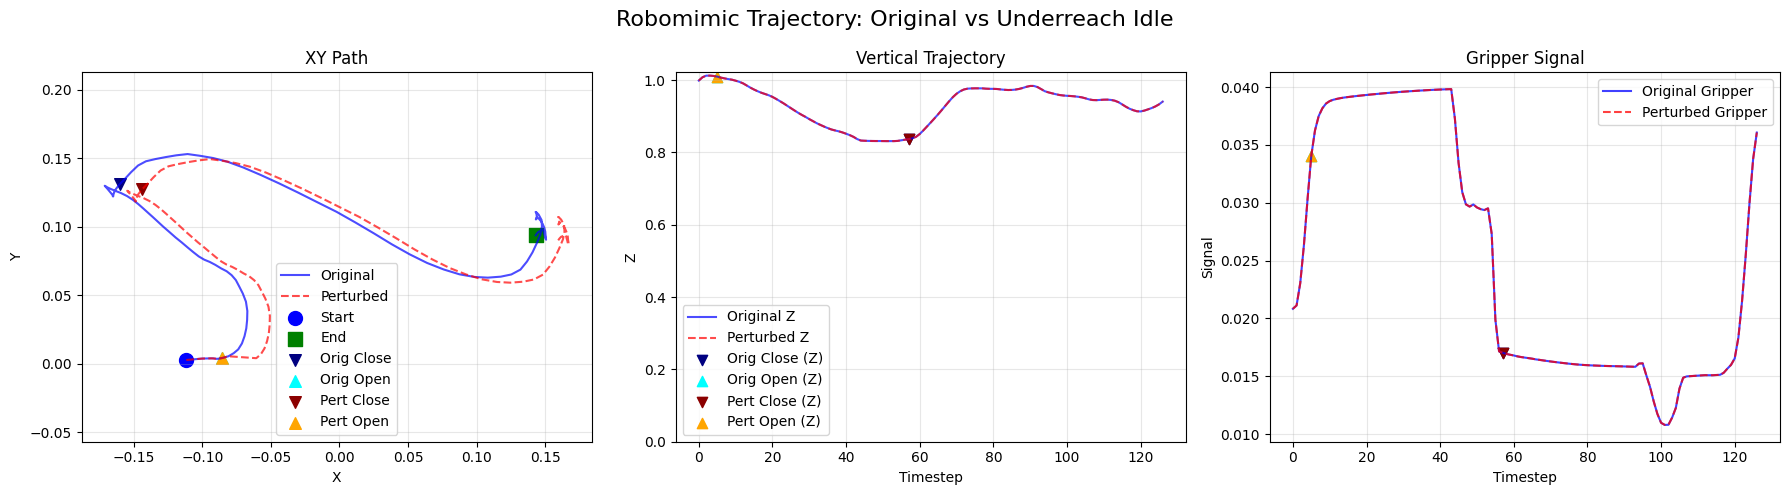

In [6]:
# Initialize generator
generator = PerturbationGenerator()

# Apply an Underreach Idle perturbation
print("Applying Underreach Idle Perturbation...")
result = generator.apply_perturbation(
    trajectory, 
    # PerturbationType.UNDERREACH_IDLE, 
    PerturbationType.LATERAL_DRIFT, 
    severity=0.5,
    seed=42
)

if result is not None:
    print(f"Success! Perturbation applied: {result.perturbation_type.name}")
    print(f"Failure Mode: {result.theoretical_failure_mode}")
    
    # Visualize the comparison
    visualize_trajectory_comparison(
        trajectory, 
        result.perturbed_trajectory, 
        title="Robomimic Trajectory: Original vs Underreach Idle"
    )
else:
    print("Perturbation not applicable for this trajectory.")

## Generate Recovery FSM

In [7]:
if result is not None:
    print("\nGenerating Recovery FSM DSL...")
    recovery_code = RecoveryCodeGenerator.generate_recovery_code(result)
    
    # Pretty print the JSON
    print(recovery_to_json(recovery_code))


Generating Recovery FSM DSL...
{
  "dsl_version": "deterministic_recovery_fsm_v1",
  "execution_model": "sequential_fsm",
  "severity_hint": "moderate",
  "parameters": {
    "perturbation_type": "lateral_drift",
    "lateral_offset_xy": [
      0.016437362913357803,
      -0.00366729361487686
    ],
    "xy_tolerance_m": 0.045,
    "speed_scale": 0.375
  },
  "robot_interface_contract": {
    "requires_live_ee_pose": true,
    "requires_gripper_state_if_used": false,
    "requires_metric_evaluator": true,
    "history_context_required": false
  },
  "program": [
    {
      "id": "S1",
      "call": "align_lateral_error(reference=\"target_or_reference_path\", frame=\"task_plane_xy\", xy_tolerance_m=0.0450, speed_scale=0.38)",
      "termination": {
        "logic": "ANY",
        "predicates": [
          {
            "lhs": "alignment_error_m",
            "cmp": "<=",
            "rhs": 0.045
          }
        ],
        "max_steps": 20
      },
      "next_on_success": "S2",
  